In [1]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import time
import matplotlib.pyplot as plt

In [2]:
tau = [jnp.linspace(0, 20, 41),
       jnp.linspace(0, 20, 41)]

hyperparameters = {
    "theta" : jnp.array([0.2, 0.2, 3.0]),
    "X0" : jnp.array([-1.0, 1.0]),
    "sigma" : jnp.array([0.2, 0.2]),
    "tau" : tau,
    # "obs_times" : test_helpers.obs_matrix(tau),
    "I" : jnp.linspace(0, 20, int(160 +1))
}

def ode(X, theta, t=None):
    '''
    X : n x D
    theta : p

    return : n x D
    '''
    n = X.shape[0]
    V, R = X.T
    a, b, c = theta # theta.repeat([n, 1]).T

    return jnp.stack([c * (V - V**3/3 + R),
                        -1/c * (V - a + b*R)])

In [3]:
data = pd.read_csv('y.csv', header=None).to_numpy()
I = np.arange(0, 20.1, 0.125)
full = np.full((I.shape[0], data.shape[1]), np.nan)
full[:,0] = I
full[np.isin(full[:,0], data[:,0])] = data

# full[:,2] = np.nan
# pd.DataFrame(full).to_csv('y_disc.csv', index=False)

In [4]:
from magi import MAGI

In [5]:
# jax.config.update("jax_default_matmul_precision", "highest")

In [6]:
dtype = jnp.float32

start = time.time()
solver = MAGI(ode, full, [1, 1, 1], theta_conf=[0,0,0], sigmas=[0.2, 0.2])

solver.put(dtype, jax.devices()[0])
end = time.time()
print(f"Initialization time: {end - start:.4f}")

start = time.time()
Xs, thetas, sigmas = solver.solve(k=200, sigma_init=0.01, mitosis_splits=2, optimizer_kwargs={'learning_rate': 0.01}, atol=0.1, rtol=0, max_iter=100)
jax.block_until_ready(thetas)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

Initialization time: 4.8300
Split 0 finished after 100 iterations | max grad = 6.58407
Split 1 finished after 100 iterations | max grad = 4.85077
Split 2 finished after 98 iterations | max grad = 0.09034
Elapsed time: 2.9861


In [7]:
solver.particles = None
start = time.time()
solver.__init__(ode, full, [1, 1, 1], theta_conf=[0,0,0], sigmas=[0.2, 0.2])
Xs, thetas, sigmas = solver.solve(k=200, sigma_init=0.01, mitosis_splits=2, optimizer_kwargs={'learning_rate': 0.01}, atol=0.1, rtol=0, max_iter=100)
jax.block_until_ready(thetas)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

Split 0 finished after 100 iterations | max grad = 6.58407
Split 1 finished after 100 iterations | max grad = 4.85077
Split 2 finished after 98 iterations | max grad = 0.09034
Elapsed time: 0.7464


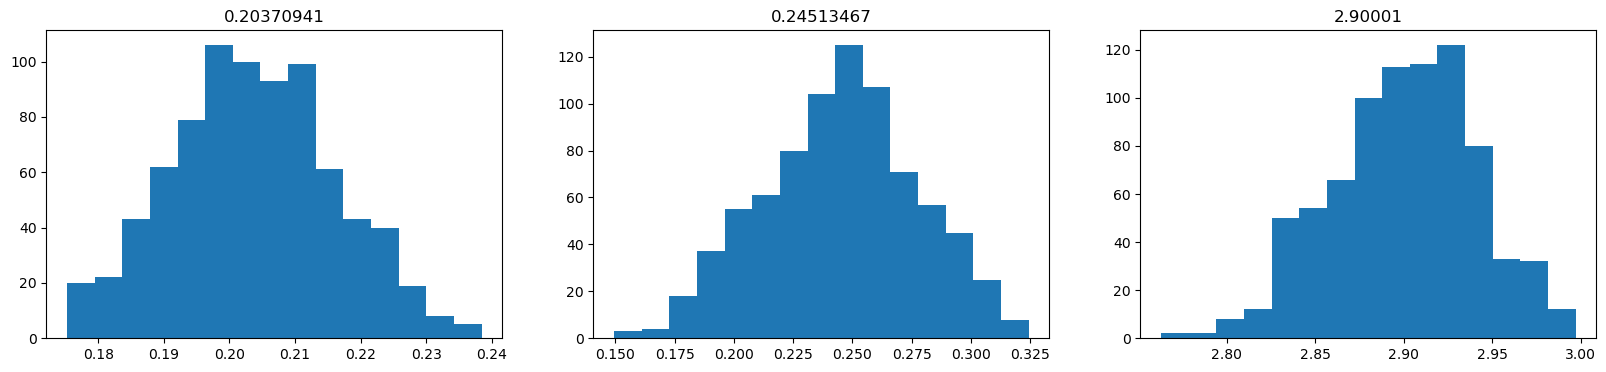

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i in range(3):
    ax[i].hist(thetas[:,i], bins=15)
    ax[i].set_title(thetas[:,i].mean())

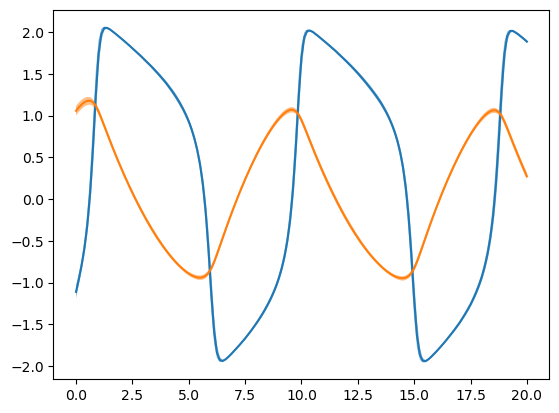

In [9]:
plt.fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,0], 0.025, axis=0), jnp.quantile(Xs[:,:,0], 0.975, axis=0), alpha=0.5)
plt.plot(solver.I, Xs.mean(axis=0)[:,0])

plt.fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,1], 0.025, axis=0), jnp.quantile(Xs[:,:,1], 0.975, axis=0), alpha=0.5)
plt.plot(solver.I, Xs.mean(axis=0)[:,1])